In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from tqdm import tqdm
from Bio.Seq import Seq
tqdm.pandas()

## Preprocessing raw data

In [ ]:
data_dir = Path("/accounts/projects/yss/stephen.lu/peint/data/dasm")
wyatt_df = pd.read_csv(data_dir / "wyatt-10x-1p5m_fs-all-NoWinCheck-UnmutInv-GTR-paired-merged_pcp_2024-11-21_DXSMVALID_no-naive_ConsCys_HL.csv", index_col=0)
vanwinkle_igh_df = pd.read_csv(data_dir / "v3convert_vanwinkle-170-igh_pcp_2025-03-05_MASKED_NI_train_no-naive_DXSMVALID_ConsCys.csv", index_col=0)
vanwinkle_igk_df = pd.read_csv(data_dir / "v3convert_vanwinkle-170-igk_pcp_2025-02-22_MASKED_NI_train_DXSMVALID_ConsCys_no-naive_downsample_500k_CONCAT_vanwinkle-170-igl_pcp_2025-02-25_MASKED_NI_train_DXSMVALID_ConsCys_no-naive_downsample_500k.csv", index_col=0)
tang_df = pd.read_csv(data_dir / "tang-deepshm-prod-NoWinCheck_igh_pcp_2024-10-29_MASKED_NI_ConsCys_no-naive_DXSMVALID.csv", index_col=0)

(209599, 30)

In [17]:
def get_edge_ids(df):
    df['family'] = df['sample_id'] + '_' + df['family'].astype(str)
    df['edge_id'] = df['family'] + ';' + df['parent_name'] + ';' + df['child_name']
    return df

def remove_aligned_gaps(seqA: str, seqB: str):
    """
    Remove gaps from seqA and seqB that are aligned to each other.
    """
    assert len(seqA) == len(seqB)
    new_seqA = []
    new_seqB = []
    for a, b in zip(seqA, seqB):
        if a != '-' or b != '-':
            new_seqA.append(a)
            new_seqB.append(b)
    assert len(new_seqA) == len(new_seqB), "Sequences are not of the same length after gap removal."
    return ''.join(new_seqA), ''.join(new_seqB)

def remove_all_gaps(seq: str) -> str:
    """
    Remove all gaps from a sequence.
    """
    return seq.replace('-', '')

def count_muts(seqA: str, seqB: str) -> int:
    """
    Count the number of mutations between two sequences.
    """
    assert len(seqA) == len(seqB)
    return sum(a != b for a, b in zip(seqA, seqB))

def handle_gaps_and_count_muts(df: pd.DataFrame) -> pd.DataFrame:
    if 'parent_heavy' not in df.columns and 'parent_light' not in df.columns:
        return df

    if 'parent_heavy' in df.columns:
        aligned_heavy = df.progress_apply(lambda x: remove_aligned_gaps(x.parent_heavy, x.child_heavy), axis=1)
        df['parent_heavy'] = aligned_heavy.progress_apply(lambda x: x[0])
        df['child_heavy'] = aligned_heavy.progress_apply(lambda x: x[1])
        df['parent_heavy_aa'] = df['parent_heavy'].progress_apply(lambda x: str(Seq(remove_all_gaps(x)).translate()))
        df['child_heavy_aa'] = df['child_heavy'].progress_apply(lambda x: str(Seq(remove_all_gaps(x)).translate()))

        df['n_mut_heavy'] = df.progress_apply(lambda x: (np.array(list(x.parent_heavy)) != np.array(list(x.child_heavy))).sum(), axis=1)
        df['n_ins_heavy'] = df.progress_apply(lambda x: (np.array(list(x.parent_heavy)) == '-').sum(), axis=1)
        df['n_del_heavy'] = df.progress_apply(lambda x: (np.array(list(x.child_heavy)) == '-').sum(), axis=1)
        df['n_sub_heavy'] = df['n_mut_heavy'] - df['n_ins_heavy'] - df['n_del_heavy']
        assert (df['n_sub_heavy'] >= 0).all(), "Negative substitutions in heavy chain."

    if 'parent_light' in df.columns:
        aligned_light = df.progress_apply(lambda x: remove_aligned_gaps(x.parent_light, x.child_light), axis=1)
        df['parent_light'] = aligned_light.progress_apply(lambda x: x[0])
        df['child_light'] = aligned_light.progress_apply(lambda x: x[1])
        df['parent_light_aa'] = df['parent_light'].progress_apply(lambda x: str(Seq(remove_all_gaps(x)).translate()))
        df['child_light_aa'] = df['child_light'].progress_apply(lambda x: str(Seq(remove_all_gaps(x)).translate()))
    
        df['n_mut_light'] = df.progress_apply(lambda x: (np.array(list(x.parent_light)) != np.array(list(x.child_light))).sum(), axis=1)
        df['n_ins_light'] = df.progress_apply(lambda x: (np.array(list(x.parent_light)) == '-').sum(), axis=1)
        df['n_del_light'] = df.progress_apply(lambda x: (np.array(list(x.child_light)) == '-').sum(), axis=1)
        df['n_sub_light'] = df['n_mut_light'] - df['n_ins_light'] - df['n_del_light']
        assert (df['n_sub_light'] >= 0).all(), "Negative substitutions in light chain."

    if 'n_mut_heavy' in df.columns and 'n_mut_light' in df.columns:
        df['n_mut'] = df['n_mut_heavy'] + df['n_mut_light']
        df['n_sub'] = df['n_sub_heavy'] + df['n_sub_light']
        df['n_del'] = df['n_del_heavy'] + df['n_del_light']
        df['n_ins'] = df['n_ins_heavy'] + df['n_ins_light']
        df['has_indels'] = df['n_ins'] + df['n_del'] > 0
    elif 'n_mut_heavy' in df.columns:
        df['n_mut'] = df['n_mut_heavy']
        df['n_sub'] = df['n_sub_heavy']
        df['n_del'] = df['n_del_heavy']
        df['n_ins'] = df['n_ins_heavy']
        df['has_indels'] = df['n_ins'] + df['n_del'] > 0
    elif 'n_mut_light' in df.columns:
        df['n_mut'] = df['n_mut_light']
        df['n_sub'] = df['n_sub_light']
        df['n_del'] = df['n_del_light']
        df['n_ins'] = df['n_ins_light']
        df['has_indels'] = df['n_ins'] + df['n_del'] > 0

    return df

In [60]:
# try pairing the heavy and light chains in the vanwinkle dataset
vanwinkle_igl_df = vanwinkle_igk_df[vanwinkle_igk_df['sample_id'].str.endswith('-igl')]
vanwinkle_igk_df = vanwinkle_igk_df[vanwinkle_igk_df['sample_id'].str.endswith('-igk')]
assert all(vanwinkle_igh_df['sample_id'].str.endswith('-igh'))
print(f"VanWinkle IGH: {len(vanwinkle_igh_df)}, IGK: {len(vanwinkle_igk_df)}, IGL: {len(vanwinkle_igl_df)}")

# Extract base sample IDs (remove chain suffix)
vanwinkle_igh_df['sample_id'] = vanwinkle_igh_df['sample_id'].str.replace('-igh', '')
vanwinkle_igl_df['sample_id'] = vanwinkle_igl_df['sample_id'].str.replace('-igl', '')
vanwinkle_igk_df['sample_id'] = vanwinkle_igk_df['sample_id'].str.replace('-igk', '')

# Create edge ids for each dataframe
vanwinkle_igh_df = get_edge_ids(vanwinkle_igh_df)
vanwinkle_igk_df = get_edge_ids(vanwinkle_igk_df)
vanwinkle_igl_df = get_edge_ids(vanwinkle_igl_df)

# Check for overlapping edges between IGH and light chains
overlap_igk = (vanwinkle_igk_df['edge_id'].isin(vanwinkle_igh_df['edge_id']) & ~vanwinkle_igk_df['edge_id'].isin(vanwinkle_igl_df['edge_id']))
overlap_igl = (vanwinkle_igl_df['edge_id'].isin(vanwinkle_igh_df['edge_id']) & ~vanwinkle_igl_df['edge_id'].isin(vanwinkle_igk_df['edge_id']))

vanwinkle_igk_df = vanwinkle_igk_df[overlap_igk]
vanwinkle_igl_df = vanwinkle_igl_df[overlap_igl]

overlap_igh = (vanwinkle_igh_df['edge_id'].isin(vanwinkle_igk_df['edge_id']) | vanwinkle_igh_df['edge_id'].isin(vanwinkle_igl_df['edge_id']))
vanwinkle_igh_df = vanwinkle_igh_df[overlap_igh]

# Check final counts
print(f"After pairing - VanWinkle IGH: {len(vanwinkle_igh_df)}, IGK: {len(vanwinkle_igk_df)}, IGL: {len(vanwinkle_igl_df)}")

VanWinkle IGH: 124985, IGK: 500000, IGL: 500000
After pairing - VanWinkle IGH: 290, IGK: 88, IGL: 202


In [63]:
merge_cols = ['sample_id', 'family', 'parent_name', 'child_name', 'edge_id']
heavy_kappa = pd.merge(vanwinkle_igh_df, vanwinkle_igk_df, on=merge_cols, how='inner', suffixes=('_heavy', '_light'))
heavy_lambd = pd.merge(vanwinkle_igh_df, vanwinkle_igl_df, on=merge_cols, how='inner', suffixes=('_heavy', '_light'))
full_df = pd.concat([heavy_kappa, heavy_lambd], axis=0)

In [66]:
from scipy.stats import spearmanr
spearmanr(full_df.branch_length_heavy, full_df.branch_length_light)

SignificanceResult(statistic=0.0736671189251092, pvalue=0.21101188438945484)

In [ ]:
df_branch_lengths_merged = pd.DataFrame({
    "Branch Length": np.concatenate([
        wyatt_df.branch_length.values,
        vanwinkle_igh_df.branch_length.values,
        vanwinkle_igk_df.branch_length.values,
        tang_df.branch_length.values,
    ]),
    "Dataset": ["Wyatt et al. 10x Genomics"] * len(wyatt_df) +
                ["VanWinkle et al. IGH"] * len(vanwinkle_igh_df) +
                ["VanWinkle et al. IGK/IGL"] * len(vanwinkle_igk_df) +
                ["Tang et al. DeepSHM"] * len(tang_df)
})

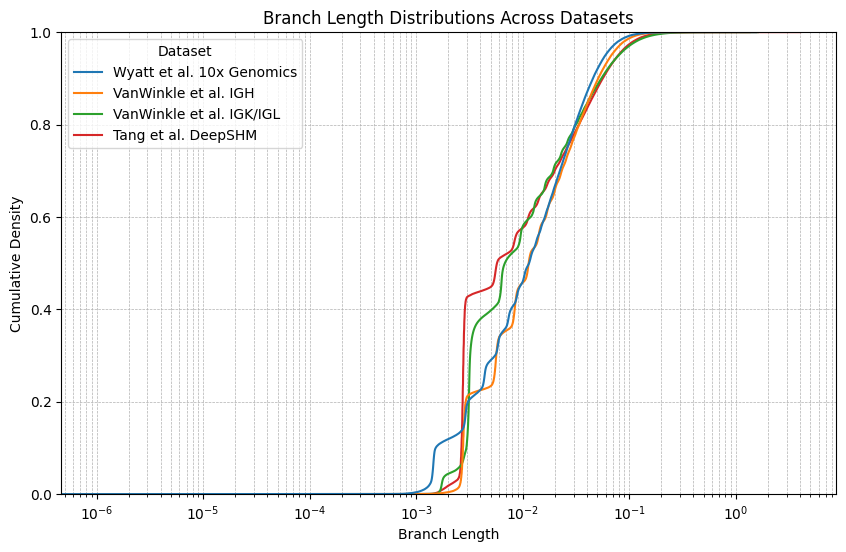

In [29]:
plt.figure(figsize=(10, 6))
sns.ecdfplot(data=df_branch_lengths_merged, x="Branch Length", hue="Dataset", legend=True)
plt.xlabel("Branch Length")
plt.xscale("log")
plt.ylabel("Cumulative Density")
plt.title("Branch Length Distributions Across Datasets")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()

In [80]:
# wyatt_df = handle_gaps_and_count_muts(wyatt_df)
vanwinkle_igh_df = handle_gaps_and_count_muts(vanwinkle_igh_df)
vanwinkle_igk_df = handle_gaps_and_count_muts(vanwinkle_igk_df)
tang_df = handle_gaps_and_count_muts(tang_df)

100%|██████████| 651935/651935 [01:40<00:00, 6463.02it/s]


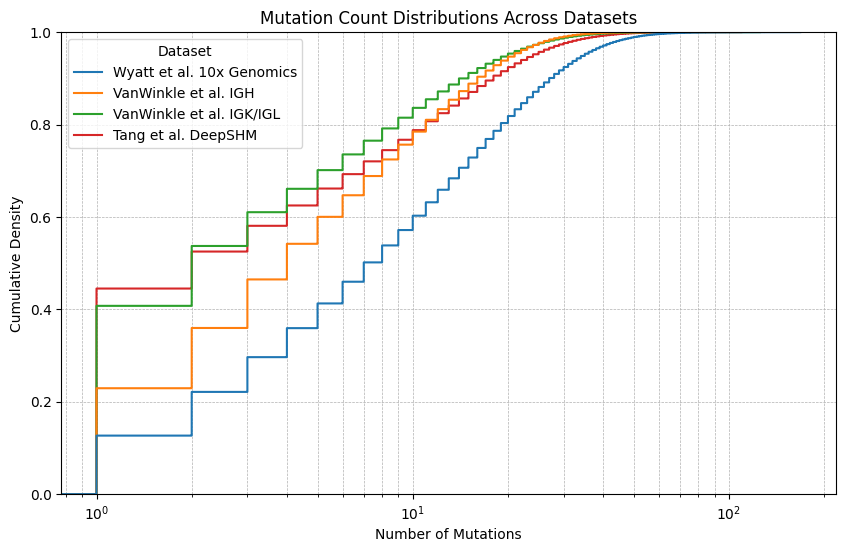

In [ ]:
# plot the mutation count cdf distributions for all datasets, similar to branch lengths
df_mut_counts_merged = pd.DataFrame({
    "Number of Mutations": np.concatenate([
        wyatt_df.n_mut.values,
        vanwinkle_igh_df.n_mut.values,
        vanwinkle_igk_df.n_mut.values,
        tang_df.n_mut.values,
    ]),
    "Dataset": ["Wyatt et al. 10x Genomics"] * len(wyatt_df) +
                ["VanWinkle et al. IGH"] * len(vanwinkle_igh_df) +
                ["VanWinkle et al. IGK/IGL"]
                * len(vanwinkle_igk_df) +
                ["Tang et al. DeepSHM"] * len(tang_df)
})  

plt.figure(figsize=(10, 6))
sns.ecdfplot(data=df_mut_counts_merged, x="Number of Mutations", hue="Dataset", legend=True)
plt.xlabel("Number of Mutations")
plt.xscale("log")
plt.ylabel("Cumulative Density")
plt.title("Mutation Count CDF Across Datasets")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()

In [82]:
# save these processed data to disk
output_dir = Path("/accounts/projects/yss/stephen.lu/peint/data/dasm/raw")
output_dir.mkdir(parents=True, exist_ok=True)
wyatt_df.to_csv(output_dir / "wyatt-paired.csv")
vanwinkle_igh_df.to_csv(output_dir / "vanwinkle-igh.csv")
vanwinkle_igk_df.to_csv(output_dir / "vanwinkle-igk.csv")
tang_df.to_csv(output_dir / "tang-igh.csv")

In [83]:
# print sizes of the raw datasets
print(f"Wyatt et al. 10x Genomics: {len(wyatt_df)}")
print(f"VanWinkle et al. IGH: {len(vanwinkle_igh_df)}")
print(f"VanWinkle et al. IGK/IGL: {len(vanwinkle_igk_df)}")
print(f"Tang et al. DeepSHM: {len(tang_df)}")

Wyatt et al. 10x Genomics: 209599
VanWinkle et al. IGH: 124985
VanWinkle et al. IGK/IGL: 1000000
Tang et al. DeepSHM: 651935


In [84]:
# remove all rows that have identical parent and child amino acid sequences (i.e. no mutations)
wyatt_df = wyatt_df[
    (wyatt_df['parent_heavy_aa'] != wyatt_df['child_heavy_aa']) |
    (wyatt_df['parent_light_aa'] != wyatt_df['child_light_aa'])
]
vanwinkle_igh_df = vanwinkle_igh_df[
    (vanwinkle_igh_df['parent_heavy_aa'] != vanwinkle_igh_df['child_heavy_aa'])
]
vanwinkle_igk_df = vanwinkle_igk_df[
    (vanwinkle_igk_df['parent_light_aa'] != vanwinkle_igk_df['child_light_aa'])
]
tang_df = tang_df[
    (tang_df['parent_heavy_aa'] != tang_df['child_heavy_aa'])
]

In [85]:
# print sizes after removing non-transitions
print(f"Wyatt et al. 10x Genomics (post-filter): {len(wyatt_df)}")
print(f"VanWinkle et al. IGH (post-filter): {len(vanwinkle_igh_df)}")
print(f"VanWinkle et al. IGK/IGL (post-filter): {len(vanwinkle_igk_df)}")
print(f"Tang et al. DeepSHM (post-filter): {len(tang_df)}")

Wyatt et al. 10x Genomics (post-filter): 196456
VanWinkle et al. IGH (post-filter): 112490
VanWinkle et al. IGK/IGL (post-filter): 855449
Tang et al. DeepSHM (post-filter): 557479


In [86]:
# remove rows with duplicate edge ids
wyatt_df = wyatt_df.drop_duplicates(subset=['edge_id'])
vanwinkle_igh_df = vanwinkle_igh_df.drop_duplicates(subset=['edge_id'])
vanwinkle_igk_df = vanwinkle_igk_df.drop_duplicates(subset=['edge_id'])
tang_df = tang_df.drop_duplicates(subset=['edge_id'])

# print sizes after removing duplicate edge ids
print(f"Wyatt et al. 10x Genomics (post-dedup): {len(wyatt_df)}")
print(f"VanWinkle et al. IGH (post-dedup): {len(vanwinkle_igh_df)}")
print(f"VanWinkle et al. IGK/IGL (post-dedup): {len(vanwinkle_igk_df)}")
print(f"Tang et al. DeepSHM (post-dedup): {len(tang_df)}")

Wyatt et al. 10x Genomics (post-dedup): 196456
VanWinkle et al. IGH (post-dedup): 112490
VanWinkle et al. IGK/IGL (post-dedup): 855449
Tang et al. DeepSHM (post-dedup): 557479


In [87]:
# save processed data to disk
output_dir = Path("/accounts/projects/yss/stephen.lu/peint/data/dasm/processed")
output_dir.mkdir(parents=True, exist_ok=True)
wyatt_df.to_csv(output_dir / "wyatt-paired.csv")
vanwinkle_igh_df.to_csv(output_dir / "vanwinkle-igh.csv")
vanwinkle_igk_df.to_csv(output_dir / "vanwinkle-igk.csv")
tang_df.to_csv(output_dir / "tang-igh.csv")

In [39]:
print(wyatt_df['parent_heavy'].iloc[0])
print(wyatt_df['child_heavy'].iloc[0])
print()
print(vanwinkle_igh_df['parent_heavy'].iloc[0])
print(vanwinkle_igh_df['child_heavy'].iloc[0])
print()
print(vanwinkle_igk_df['parent_light'].iloc[0])
print(vanwinkle_igk_df['child_light'].iloc[0])
print()
print(tang_df['parent_heavy'].iloc[0])
print(tang_df['child_heavy'].iloc[0])
print()

CAGGTGCAGCTGGTGCAATCTGGGTCTGAGTTGAAGAGGCCTGGGGCCTCAGTGAAGGTTTCCTGCAAGGCTTCTGGATACACCTTCACTAGTCATCCTATAAATTGGGTGCGACAGGTCCCTGGACAGGGGCTTGAGTGGATGGGATGGATCAACACCAACACTGGGAACCCAACGTATGCCCAGGGCTTCACAGGACGGTTTGTCTTGTCCTTGGACACCTCTGTCAGCACGGCATATCTGCAGATCAGCAGCCTAAAGGCTGAGGACACTGCCGTATATTACTGTGCGAGAGATAGGTGGGATAACGATCTTTTAATTGGCCTTGAGTATTGGGGCCAGGGAACCCTGGTCACCGTCTCCTCA
CAGGTGCAGCTGGTGCAATCTGGGTCTGAGTTGAAGAGGCCTGGGGCCTCAGTGAAGGTTTCCTGCAAGGCTTCTGGATACACCTTCACTAGTCATCCTATAAATTGGGTGCGACAGGTCCCTGGACAGGGGCTTGAGTGGATGGGATGGATCAACACCAACACTGGGAACCCAACGTATGCCCAGGGCTTCACAGGACGCTTTGTCTTGTCATCGGACACCTCTGTCAGCACGGCATATCTGCAGATCAGCAGCCTAAAGGCTGAGGACACTGCCGTATATTACTGTGCGAGAGATAGGTGGGATAACGATCTTTTAATTGGCCTTGAGTATTGGGGCCAGGGAACCCTGGTCACCGTCTCCTCA

GAGGTGCAACTGGTGGAGTCTGGAGGAGGCTTGATCCAGCCGGGGGGGTCCCTGAGACTCTCCTGTGCAGCCTCGGGTTTCGCCGTCGGCACTACCTACATGGCCTGGGTCCGCCAGGCTCCAGGGAAGGGGCTGCAGTGGGTCTCAGTCATTTATACCTATGGCAACACAGACTACGCAGACTCCGTGAAGGGCCGATTCACCATCTCCAGAGACAATTCCAAGAACACGCTGTCTCTTCAAATGAGCAGCGTTAGAGCCGAGG

## Post processing to get transitions

In [3]:
data_dir = Path("/accounts/projects/yss/stephen.lu/peint/data/dasm/processed")
wyatt_df = pd.read_csv(data_dir / "wyatt-paired.csv", index_col=0)
vanwinkle_igh_df = pd.read_csv(data_dir / "vanwinkle-igh.csv", index_col=0)
vanwinkle_igk_df = pd.read_csv(data_dir / "vanwinkle-igk.csv", index_col=0)
tang_df = pd.read_csv(data_dir / "tang-igh.csv", index_col=0)

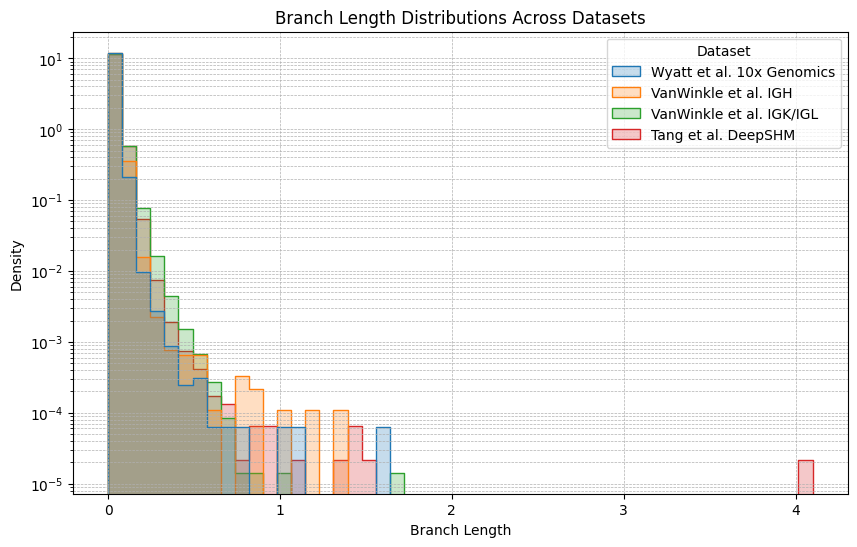

In [6]:
df_branch_lengths_merged = pd.DataFrame({
    "Branch Length": np.concatenate([
        wyatt_df.branch_length.values,
        vanwinkle_igh_df.branch_length.values,
        vanwinkle_igk_df.branch_length.values,
        tang_df.branch_length.values,
    ]),
    "Dataset": ["Wyatt et al. 10x Genomics"] * len(wyatt_df) +
                ["VanWinkle et al. IGH"] * len(vanwinkle_igh_df) +
                ["VanWinkle et al. IGK/IGL"] * len(vanwinkle_igk_df) +
                ["Tang et al. DeepSHM"] * len(tang_df)
})

# plot histogram of branch lengths on log scale
plt.figure(figsize=(10, 6))
sns.histplot(data=df_branch_lengths_merged, x="Branch Length", hue="Dataset", element="step", stat="density", common_norm=False, bins=50)
plt.xlabel("Branch Length")
plt.yscale("log")
plt.ylabel("Density")
plt.title("Branch Length Distributions Across Datasets")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()

## Analyze codon distribution of different datasets compared to Koenig

In [5]:
from evo.sequence import HUMAN_CODON_USAGE
from evo.antibody import KOENIG_IGH_CON_SEQ, KOENIG_IGK_CON_SEQ
from collections import Counter

In [6]:
data_dir = Path("/accounts/projects/yss/stephen.lu/peint/data/dasm/processed")
wyatt_df = pd.read_csv(data_dir / "wyatt-paired.csv", index_col=0)
vanwinkle_igh_df = pd.read_csv(data_dir / "vanwinkle-igh.csv", index_col=0)
vanwinkle_igk_df = pd.read_csv(data_dir / "vanwinkle-igk.csv", index_col=0)
tang_df = pd.read_csv(data_dir / "tang-igh.csv", index_col=0)
jaffe_df = pd.read_csv("/accounts/projects/yss/stephen.lu/peint/data/wyatt/all/peint_df.csv.gz", index_col=0, compression='gzip')
koenig_df = pd.read_csv("/scratch/users/stephen.lu/projects/protevo/data/flab/Koenig2017_g6_Kd.csv")

In [7]:
def compute_codon_usage_counts(sequence: str) -> dict:
    codon_counts = Counter()
    for i in range(0, len(sequence) - 2, 3):
        codon = sequence[i:i+3]
        if codon in HUMAN_CODON_USAGE:
            codon_counts[codon] += 1
    return codon_counts

def compute_aa_usage_counts(sequence: str) -> dict:
    aa_counts = Counter()
    for aa in sequence:
        aa_counts[aa] += 1
    return aa_counts

In [8]:
n_samples = 10000
seed = 42

def sampled_counts(df, col):
    n = min(n_samples, len(df))
    return df[col].sample(n=n, random_state=seed).progress_apply(compute_codon_usage_counts).tolist()

def sampled_aa_counts(df, col):
    n = min(n_samples, len(df))
    return df[col].sample(n=n, random_state=seed).progress_apply(compute_aa_usage_counts).tolist()

wyatt_heavy_counts = sampled_counts(wyatt_df, 'parent_heavy')
wyatt_heavy_counts = sum(wyatt_heavy_counts, Counter())

wyatt_light_counts = sampled_counts(wyatt_df, 'parent_light')
wyatt_light_counts = sum(wyatt_light_counts, Counter())

jaffe_heavy_counts = sampled_counts(jaffe_df, 'parent_heavy')
jaffe_heavy_counts = sum(jaffe_heavy_counts, Counter())

jaffe_light_counts = sampled_counts(jaffe_df, 'parent_light')
jaffe_light_counts = sum(jaffe_light_counts, Counter())

vanwinkle_heavy_counts = sampled_counts(vanwinkle_igh_df, 'parent_heavy')
vanwinkle_heavy_counts = sum(vanwinkle_heavy_counts, Counter())

vanwinkle_light_counts = sampled_counts(vanwinkle_igk_df, 'parent_light')
vanwinkle_light_counts = sum(vanwinkle_light_counts, Counter())

tang_heavy_counts = sampled_counts(tang_df, 'parent_heavy')
tang_heavy_counts = sum(tang_heavy_counts, Counter())

koenig_heavy_counts = [compute_codon_usage_counts(KOENIG_IGH_CON_SEQ)]
koenig_light_counts = [compute_codon_usage_counts(KOENIG_IGK_CON_SEQ)]

koenig_heavy_counts = sum(koenig_heavy_counts, Counter())
koenig_light_counts = sum(koenig_light_counts, Counter())

wyatt_aa_heavy_counts = sampled_aa_counts(wyatt_df, 'parent_heavy_aa')
wyatt_aa_heavy_counts = sum(wyatt_aa_heavy_counts, Counter())

wyatt_aa_light_counts = sampled_aa_counts(wyatt_df, 'parent_light_aa')
wyatt_aa_light_counts = sum(wyatt_aa_light_counts, Counter())

jaffe_aa_heavy_counts = sampled_aa_counts(jaffe_df, 'parent_heavy_aa')
jaffe_aa_heavy_counts = sum(jaffe_aa_heavy_counts, Counter())

jaffe_aa_light_counts = sampled_aa_counts(jaffe_df, 'parent_light_aa')
jaffe_aa_light_counts = sum(jaffe_aa_light_counts, Counter())

vanwinkle_aa_heavy_counts = sampled_aa_counts(vanwinkle_igh_df, 'parent_heavy_aa')
vanwinkle_aa_heavy_counts = sum(vanwinkle_aa_heavy_counts, Counter())

vanwinkle_aa_light_counts = sampled_aa_counts(vanwinkle_igk_df, 'parent_light_aa')
vanwinkle_aa_light_counts = sum(vanwinkle_aa_light_counts, Counter())

tang_aa_heavy_counts = sampled_aa_counts(tang_df, 'parent_heavy_aa')
tang_aa_heavy_counts = sum(tang_aa_heavy_counts, Counter())

koenig_aa_heavy_counts = [compute_aa_usage_counts(str(Seq(KOENIG_IGH_CON_SEQ).translate()))]
koenig_aa_light_counts = [compute_aa_usage_counts(str(Seq(KOENIG_IGK_CON_SEQ).translate()))]

koenig_aa_heavy_counts = sum(koenig_aa_heavy_counts, Counter())
koenig_aa_light_counts = sum(koenig_aa_light_counts, Counter())

100%|██████████| 10000/10000 [00:00<00:00, 26607.07it/s]


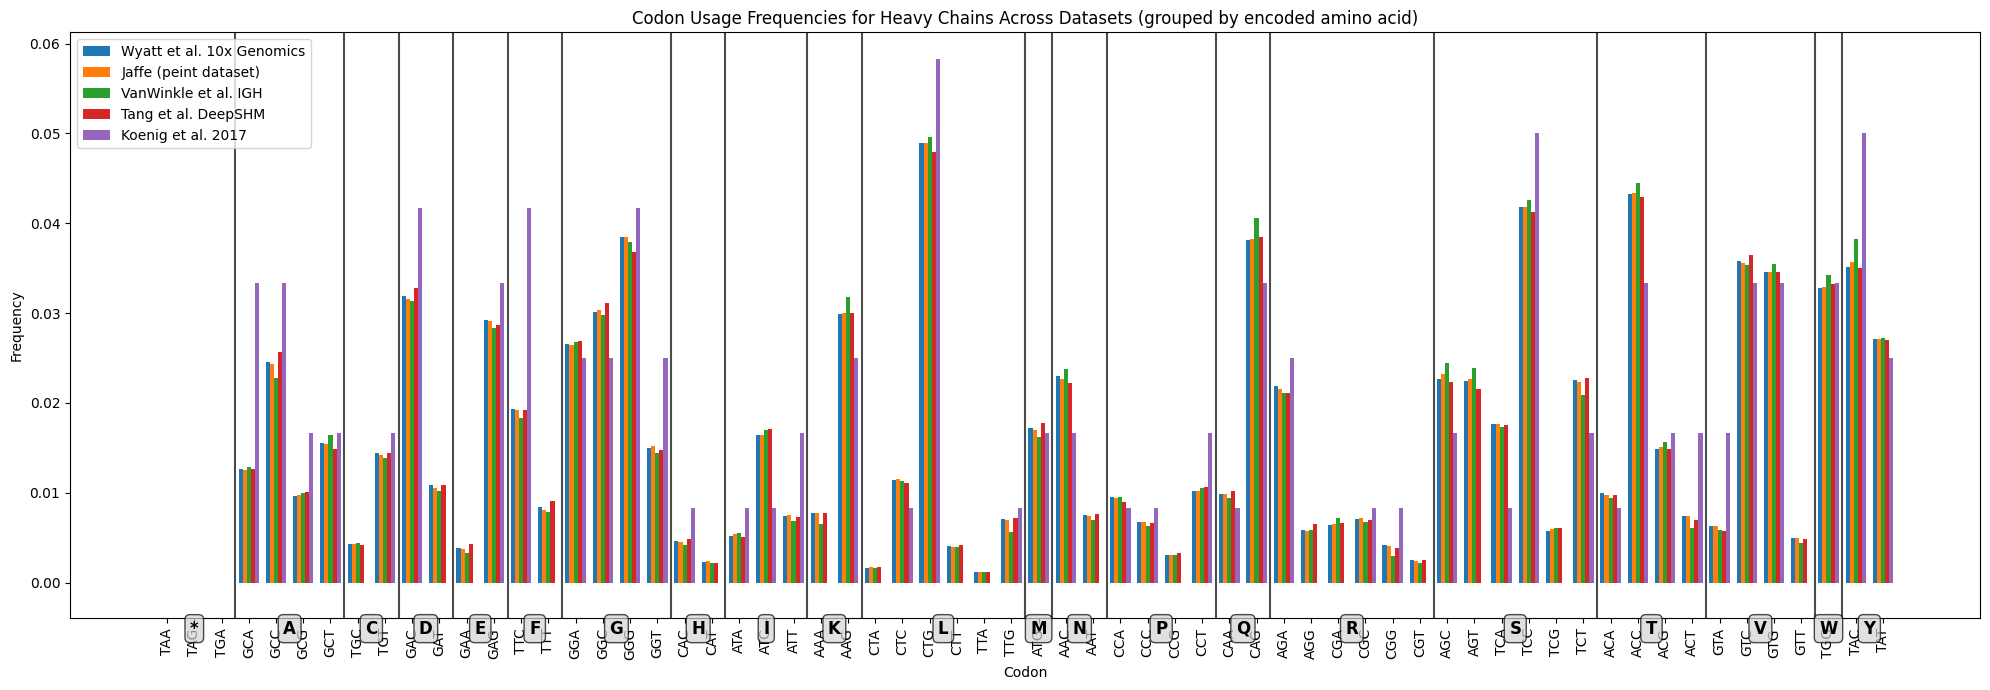

In [9]:
from collections import OrderedDict

# Get valid codons
codons = sorted([c for c in HUMAN_CODON_USAGE.keys() if len(c) == 3 and set(c).issubset({'A', 'T', 'G', 'C'})])

# Create proper codon to amino acid mapping
codon_to_aa = {}
for c in codons:
    try:
        aa = str(Seq(c).translate())
        codon_to_aa[c] = aa
    except:
        continue  # Skip invalid codons

# Filter codons to only those with valid translations
valid_codons = [c for c in codons if c in codon_to_aa]

# **KEY FIX**: Sort codons by amino acid first, then by codon
# This ensures all codons for the same AA are grouped together
valid_codons = sorted(valid_codons, key=lambda c: (codon_to_aa[c], c))

# Now get frequencies for the properly sorted codons
wyatt_heavy_freqs = [wyatt_heavy_counts.get(codon, 0) / sum(wyatt_heavy_counts.values()) for codon in valid_codons]
jaffe_heavy_freqs = [jaffe_heavy_counts.get(codon, 0) / sum(jaffe_heavy_counts.values()) for codon in valid_codons]
vanwinkle_heavy_freqs = [vanwinkle_heavy_counts.get(codon, 0) / sum(vanwinkle_heavy_counts.values()) for codon in valid_codons]
tang_heavy_freqs = [tang_heavy_counts.get(codon, 0) / sum(tang_heavy_counts.values()) for codon in valid_codons]
koenig_heavy_freqs = [koenig_heavy_counts.get(codon, 0) / sum(koenig_heavy_counts.values()) for codon in valid_codons]

# Build ordered groups by amino acid
aa_groups = OrderedDict()
for i, c in enumerate(valid_codons):
    aa = codon_to_aa[c]
    aa_groups.setdefault(aa, []).append((i, c))

# Prepare plot
x = np.arange(len(valid_codons))
width = 0.15  # width of the bars

fig, ax = plt.subplots(figsize=(20, 7))
ax.bar(x - 2*width, wyatt_heavy_freqs, width, label='Wyatt et al. 10x Genomics')
ax.bar(x - width, jaffe_heavy_freqs, width, label='Jaffe (peint dataset)')
ax.bar(x, vanwinkle_heavy_freqs, width, label='VanWinkle et al. IGH')
ax.bar(x + width, tang_heavy_freqs, width, label='Tang et al. DeepSHM')
ax.bar(x + 2*width, koenig_heavy_freqs, width, label='Koenig et al. 2017')

# Set ticks and codon labels
ax.set_xticks(x)
ax.set_xticklabels(valid_codons, rotation=90)
ax.set_xlabel('Codon')
ax.set_ylabel('Frequency')
ax.set_title('Codon Usage Frequencies for Heavy Chains Across Datasets (grouped by encoded amino acid)')

# Draw group separators and add amino-acid labels
for aa, items in aa_groups.items():
    indices = [idx for idx, _ in items]
    left = min(indices)
    right = max(indices)
    center = (left + right) / 2.0
    
    # Vertical separator at the right edge of the group (except after last group)
    if right < len(valid_codons) - 1:
        ax.axvline(right + 0.5, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
    
    # Place amino-acid labels below the x-axis at group centers
    ax.text(center, -0.002, aa, transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.7))

# Improve layout
ax.set_ylim(bottom=-0.004)
plt.subplots_adjust(bottom=0.15)
ax.legend()
plt.tight_layout()
plt.show()

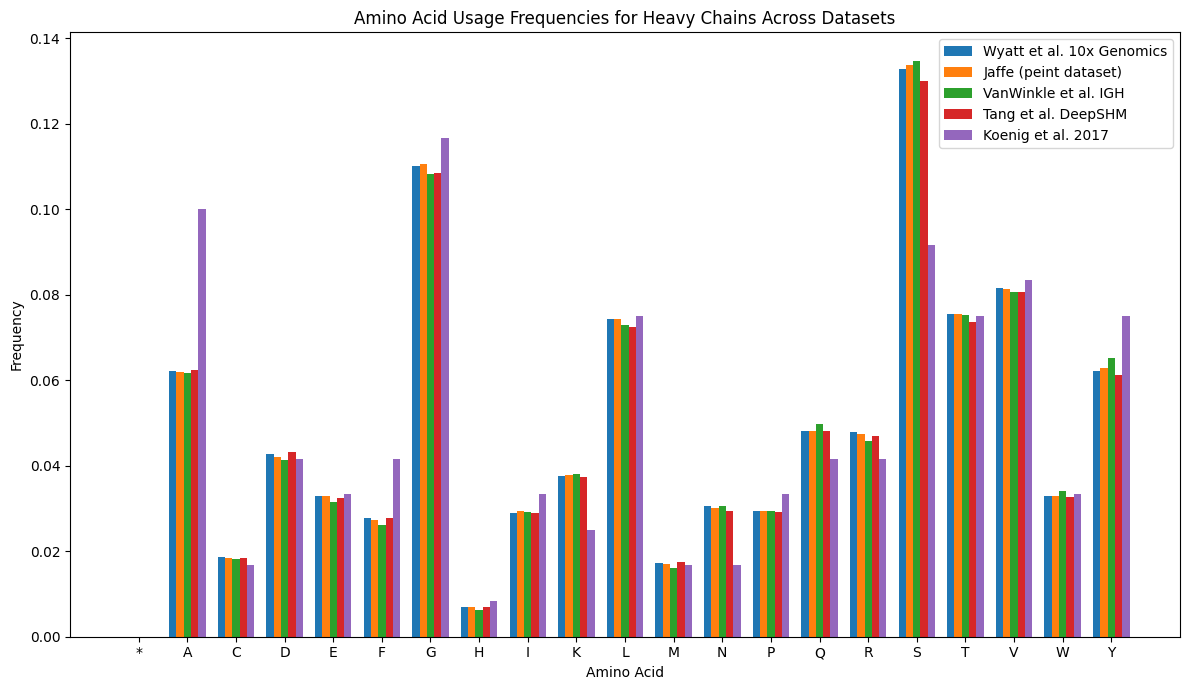

In [10]:
# not plot the heavy chain amino acid frequency distribution for the same datasets
valid_aas = sorted(set(codon_to_aa.values()))
wyatt_aa_heavy_freqs = [wyatt_aa_heavy_counts.get(aa, 0) / sum(wyatt_aa_heavy_counts.values()) for aa in valid_aas]
jaffe_aa_heavy_freqs = [jaffe_aa_heavy_counts.get(aa, 0) / sum(jaffe_aa_heavy_counts.values()) for aa in valid_aas]
vanwinkle_aa_heavy_freqs = [vanwinkle_aa_heavy_counts.get(aa, 0) / sum(vanwinkle_aa_heavy_counts.values()) for aa in valid_aas]
tang_aa_heavy_freqs = [tang_aa_heavy_counts.get(aa, 0) / sum(tang_aa_heavy_counts.values()) for aa in valid_aas]
koenig_aa_heavy_freqs = [koenig_aa_heavy_counts.get(aa, 0) / sum(koenig_aa_heavy_counts.values()) for aa in valid_aas]

x = np.arange(len(sorted(wyatt_aa_heavy_counts.keys())))
width = 0.15  # width of the bars
fig, ax = plt.subplots(figsize=(12, 7))
ax.bar(x - 2*width, wyatt_aa_heavy_freqs, width, label='Wyatt et al. 10x Genomics')
ax.bar(x - width, jaffe_aa_heavy_freqs, width, label='Jaffe (peint dataset)')
ax.bar(x, vanwinkle_aa_heavy_freqs, width, label='VanWinkle et al. IGH')
ax.bar(x + width, tang_aa_heavy_freqs, width, label='Tang et al. DeepSHM')
ax.bar(x + 2*width, koenig_aa_heavy_freqs, width, label='Koenig et al. 2017')
ax.set_xticks(x)
ax.set_xticklabels(valid_aas)
ax.set_xlabel('Amino Acid')
ax.set_ylabel('Frequency')
ax.set_title('Amino Acid Usage Frequencies for Heavy Chains Across Datasets')
plt.subplots_adjust(bottom=0.15)
ax.legend()
plt.tight_layout()
plt.show()

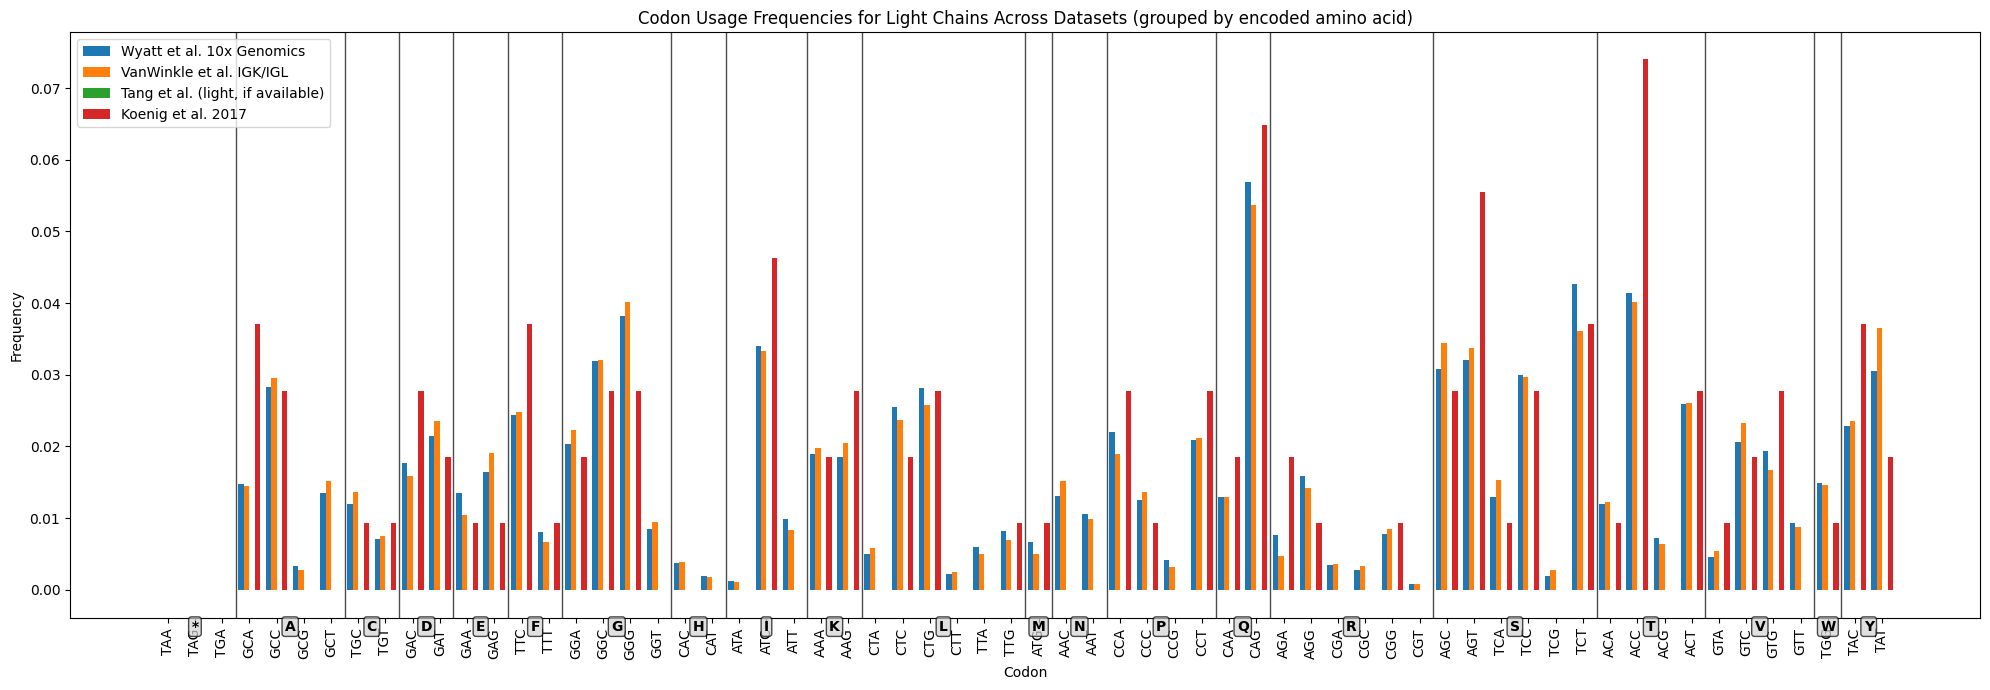

In [14]:
# Convert plot to use light chains instead of heavy chains

# Get valid codons
codons = sorted([c for c in HUMAN_CODON_USAGE.keys() if len(c) == 3 and set(c).issubset({'A', 'T', 'G', 'C'})])

# Create codon -> AA mapping
codon_to_aa = {}
for c in codons:
    try:
        codon_to_aa[c] = str(Seq(c).translate())
    except:
        continue

valid_codons = [c for c in codons if c in codon_to_aa]
valid_codons = sorted(valid_codons, key=lambda c: (codon_to_aa[c], c))

# helper to get frequencies safely
def freqs_from_counts(counter, codon_list):
    total = sum(counter.values()) if counter is not None else 0
    if total == 0:
        return [0.0] * len(codon_list)
    return [counter.get(c, 0) / total for c in codon_list]

# Obtain light-chain counters (fall back to empty Counter if missing)
from collections import Counter
wyatt_cnt = wyatt_light_counts
vanwinkle_cnt = vanwinkle_light_counts
koenig_cnt = koenig_light_counts
tang_cnt = globals().get('tang_light_counts', Counter())

# Compute frequencies for light chains
wyatt_light_freqs = freqs_from_counts(wyatt_cnt, valid_codons)
vanwinkle_light_freqs = freqs_from_counts(vanwinkle_cnt, valid_codons)
tang_light_freqs = freqs_from_counts(tang_cnt, valid_codons)
koenig_light_freqs = freqs_from_counts(koenig_cnt, valid_codons)

# Build AA groups for labeling
aa_groups = OrderedDict()
for i, c in enumerate(valid_codons):
    aa = codon_to_aa[c]
    aa_groups.setdefault(aa, []).append((i, c))

# Plot
x = np.arange(len(valid_codons))
width = 0.2
fig, ax = plt.subplots(figsize=(20, 7))

ax.bar(x - 1.5*width, wyatt_light_freqs, width, label='Wyatt et al. 10x Genomics')
ax.bar(x - 0.5*width, vanwinkle_light_freqs, width, label='VanWinkle et al. IGK/IGL')
ax.bar(x + 0.5*width, tang_light_freqs, width, label='Tang et al. (light, if available)')
ax.bar(x + 1.5*width, koenig_light_freqs, width, label='Koenig et al. 2017')

ax.set_xticks(x)
ax.set_xticklabels(valid_codons, rotation=90)
ax.set_xlabel('Codon')
ax.set_ylabel('Frequency')
ax.set_title('Codon Usage Frequencies for Light Chains Across Datasets (grouped by encoded amino acid)')

# Group separators and AA labels
for aa, items in aa_groups.items():
    indices = [idx for idx, _ in items]
    left = min(indices); right = max(indices)
    center = (left + right) / 2.0
    if right < len(valid_codons) - 1:
        ax.axvline(right + 0.5, color='black', linestyle='-', linewidth=1.0, alpha=0.7)
    ax.text(center, -0.002, aa, transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='lightgray', alpha=0.7))

ax.set_ylim(bottom=-0.004)
plt.subplots_adjust(bottom=0.15)
ax.legend()
plt.tight_layout()
plt.show()

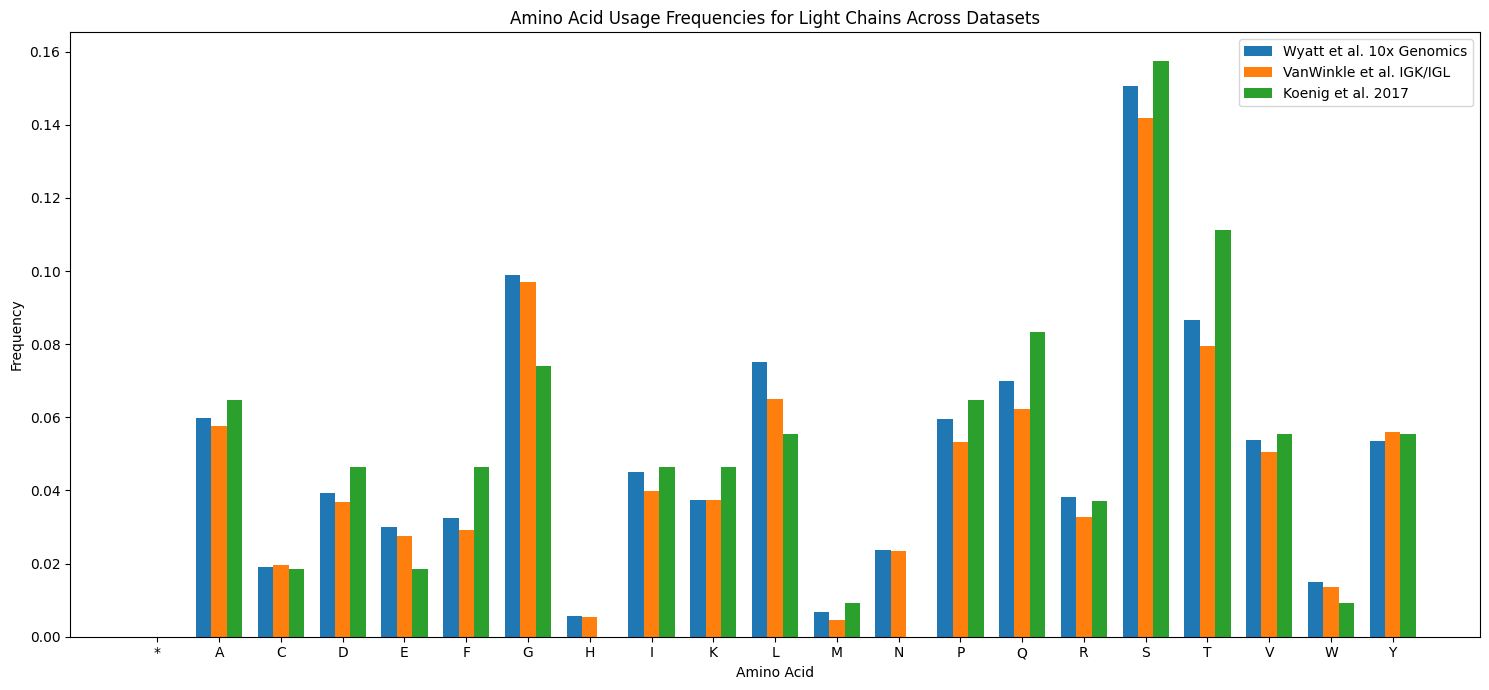

In [15]:
# plot the amino acid frequency distribution for light chains for the same datasets
valid_aas = sorted(set(codon_to_aa.values()))
wyatt_aa_light_freqs = [wyatt_aa_light_counts.get(aa, 0) / sum(wyatt_aa_light_counts.values()) for aa in valid_aas]
vanwinkle_aa_light_freqs = [vanwinkle_aa_light_counts.get(aa, 0) / sum(vanwinkle_aa_light_counts.values()) for aa in valid_aas]
koenig_aa_light_freqs = [koenig_aa_light_counts.get(aa, 0) / sum(koenig_aa_light_counts.values()) for aa in valid_aas]
x = np.arange(len(sorted(wyatt_aa_light_counts.keys())))
width = 0.25
fig, ax = plt.subplots(figsize=(15, 7))
ax.bar(x - width, wyatt_aa_light_freqs, width, label='Wyatt et al. 10x Genomics')
ax.bar(x, vanwinkle_aa_light_freqs, width, label='VanWinkle et al. IGK/IGL')
ax.bar(x + width, koenig_aa_light_freqs, width, label='Koenig et al. 2017')
ax.set_xticks(x)
ax.set_xticklabels(valid_aas)
ax.set_xlabel('Amino Acid')
ax.set_ylabel('Frequency')
ax.set_title('Amino Acid Usage Frequencies for Light Chains Across Datasets')
plt.subplots_adjust(bottom=0.15)
ax.legend()
plt.tight_layout()
plt.show()

100%|██████████| 557479/557479 [00:01<00:00, 413036.58it/s]


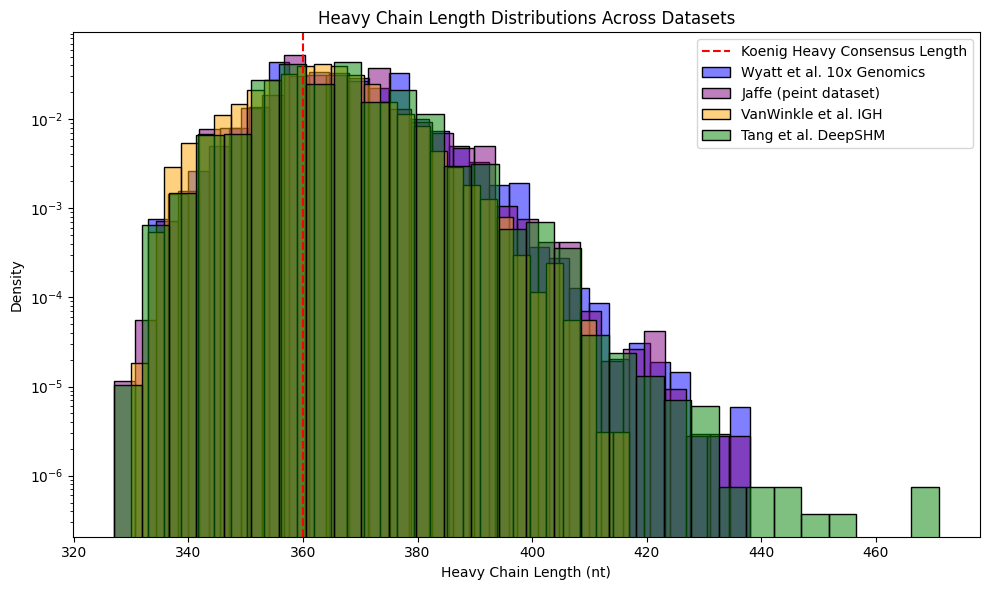

In [21]:
# once again, sample n_samples from the heavy chains of each dataset and plot the length distribution in a histplot, draw a vertical line where the IGHV3-23 length is
ighv3_23_length = len(KOENIG_IGH_CON_SEQ)

wyatt_heavy_lengths = wyatt_df['parent_heavy'].progress_apply(lambda x: len(remove_all_gaps(x)))
jaffe_heavy_lengths = jaffe_df['parent_heavy'].progress_apply(lambda x: len(remove_all_gaps(x)))
vanwinkle_heavy_lengths = vanwinkle_igh_df['parent_heavy'].progress_apply(lambda x: len(remove_all_gaps(x)))
tang_heavy_lengths = tang_df['parent_heavy'].progress_apply(lambda x: len(remove_all_gaps(x)))

plt.figure(figsize=(10, 6))
sns.histplot(wyatt_heavy_lengths, color='blue', label='Wyatt et al. 10x Genomics', stat='density', bins=30, alpha=0.5)
sns.histplot(jaffe_heavy_lengths, color='purple', label='Jaffe (peint dataset)', stat='density', bins=30, alpha=0.5)
sns.histplot(vanwinkle_heavy_lengths, color='orange', label='VanWinkle et al. IGH', stat='density', bins=30, alpha=0.5)
sns.histplot(tang_heavy_lengths, color='green', label='Tang et al. DeepSHM', stat='density', bins=30, alpha=0.5)
plt.axvline(ighv3_23_length, color='red', linestyle='--', label='Koenig Heavy Consensus Length')
plt.xlabel('Heavy Chain Length (nt)')
plt.ylabel('Density')
plt.yscale('log')
plt.title('Heavy Chain Length Distributions Across Datasets')
plt.legend()
plt.tight_layout()
plt.show()

100%|██████████| 855449/855449 [00:02<00:00, 419243.92it/s]


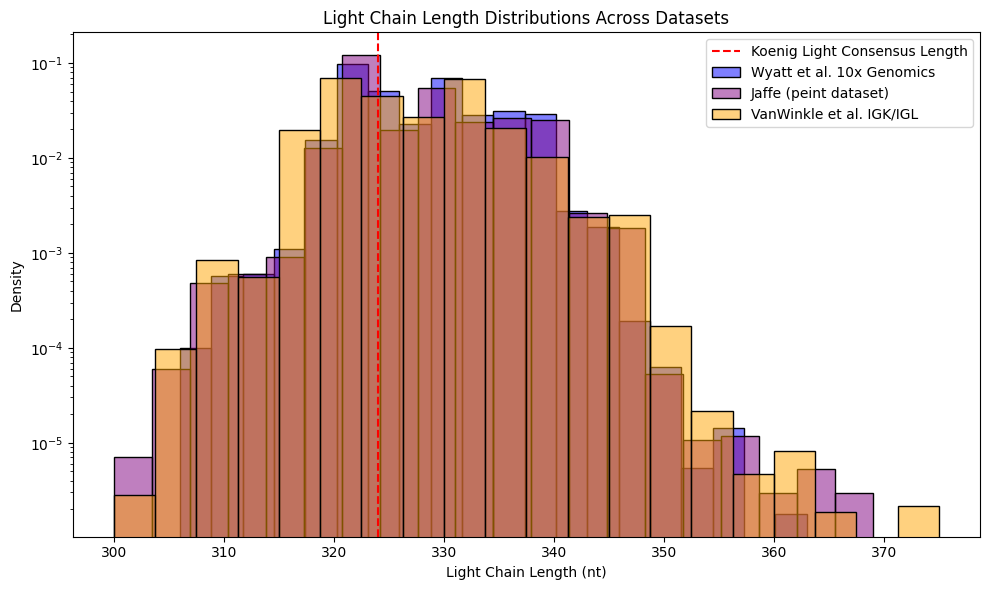

In [22]:
# do the same thing for light chains, drawing a vertical line where IGKV1-39 length is
igkv1_39_length = len(KOENIG_IGK_CON_SEQ)
wyatt_light_lengths = wyatt_df['parent_light'].progress_apply(lambda x: len(remove_all_gaps(x)))
jaffe_light_lengths = jaffe_df['parent_light'].progress_apply(lambda x: len(remove_all_gaps(x)))
vanwinkle_light_lengths = vanwinkle_igk_df['parent_light'].progress_apply(lambda x: len(remove_all_gaps(x)))

plt.figure(figsize=(10, 6))
sns.histplot(wyatt_light_lengths, color='blue', label='Wyatt et al. 10x Genomics', stat='density', bins=20, alpha=0.5)
sns.histplot(jaffe_light_lengths, color='purple', label='Jaffe (peint dataset)', stat='density', bins=20, alpha=0.5)
sns.histplot(vanwinkle_light_lengths, color='orange', label='VanWinkle et al. IGK/IGL', stat='density', bins=20, alpha=0.5)
plt.axvline(igkv1_39_length, color='red', linestyle='--', label='Koenig Light Consensus Length')
plt.xlabel('Light Chain Length (nt)')
plt.ylabel('Density')
plt.yscale('log')
plt.title('Light Chain Length Distributions Across Datasets')
plt.legend()
plt.tight_layout()
plt.show()

100%|██████████| 10000/10000 [00:00<00:00, 10008.44it/s]


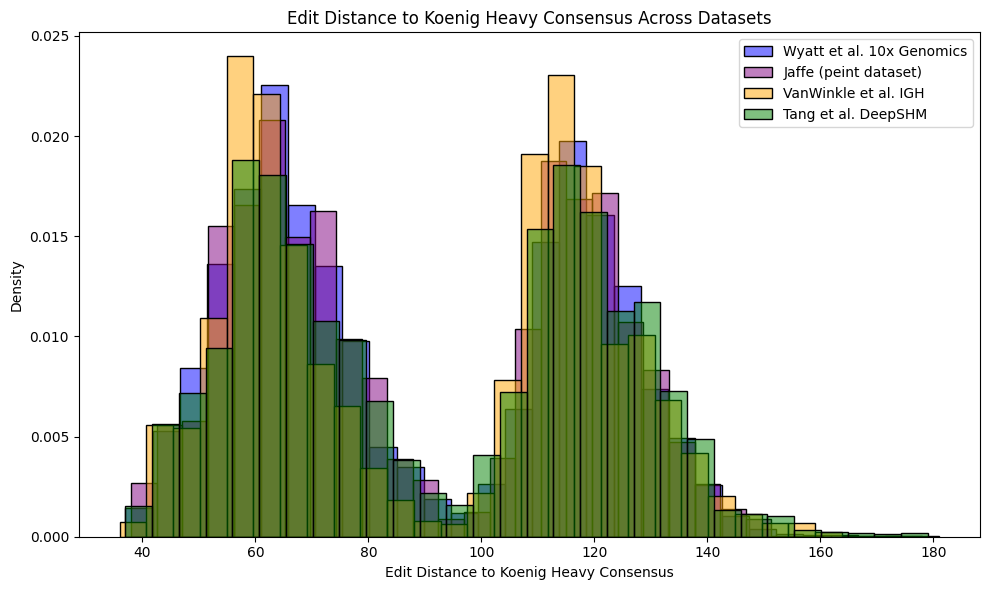

In [24]:
import editdistance

# for each dataset, sample n_samples rows and compute the edit distance between the heavy parent and IGHV3-23_04_SEQ
wyatt_heavy_edit_distances = wyatt_df.sample(n=min(n_samples, len(wyatt_df)), random_state=seed).progress_apply(lambda x: editdistance.eval(remove_all_gaps(x.parent_heavy), KOENIG_IGH_CON_SEQ), axis=1)
jaffe_heavy_edit_distances = jaffe_df.sample(n=min(n_samples, len(jaffe_df)), random_state=seed).progress_apply(lambda x: editdistance.eval(remove_all_gaps(x.parent_heavy), KOENIG_IGH_CON_SEQ), axis=1)
vanwinkle_heavy_edit_distances = vanwinkle_igh_df.sample(n=min(n_samples, len(vanwinkle_igh_df)), random_state=seed).progress_apply(lambda x: editdistance.eval(remove_all_gaps(x.parent_heavy), KOENIG_IGH_CON_SEQ), axis=1)
tang_heavy_edit_distances = tang_df.sample(n=min(n_samples, len(tang_df)), random_state=seed).progress_apply(lambda x: editdistance.eval(remove_all_gaps(x.parent_heavy), KOENIG_IGH_CON_SEQ), axis=1)

# plot histogram of edit distances
plt.figure(figsize=(10, 6))
sns.histplot(wyatt_heavy_edit_distances, color='blue', label='Wyatt et al. 10x Genomics', stat='density', bins=30, alpha=0.5)
sns.histplot(jaffe_heavy_edit_distances, color='purple', label='Jaffe (peint dataset)', stat='density', bins=30, alpha=0.5)
sns.histplot(vanwinkle_heavy_edit_distances, color='orange', label='VanWinkle et al. IGH', stat='density', bins=30, alpha=0.5)
sns.histplot(tang_heavy_edit_distances, color='green', label='Tang et al. DeepSHM', stat='density', bins=30, alpha=0.5)
plt.xlabel('Edit Distance to Koenig Heavy Consensus')
plt.ylabel('Density')
plt.title('Edit Distance to Koenig Heavy Consensus Across Datasets')
plt.legend()
plt.tight_layout()
plt.show()

100%|██████████| 10000/10000 [00:00<00:00, 11088.54it/s]


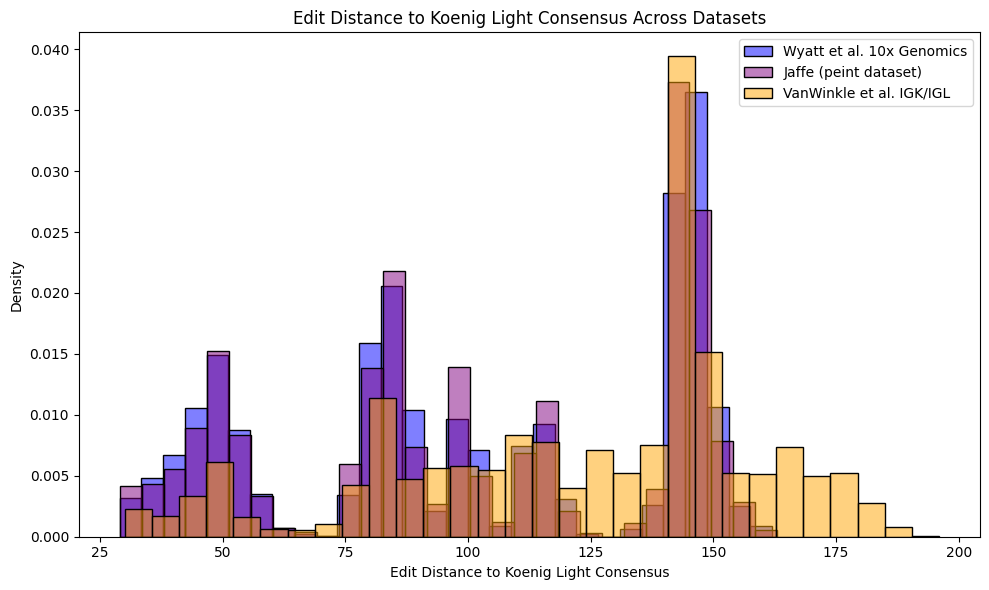

In [23]:
# for each dataset, sample n_samples rows and compute the edit distance between the light parent and IGKV1-39_SEQ
wyatt_light_edit_distances = wyatt_df.sample(n=min(n_samples, len(wyatt_df)), random_state=seed).progress_apply(lambda x: editdistance.eval(remove_all_gaps(x.parent_light), KOENIG_IGK_CON_SEQ), axis=1)
jaffe_light_edit_distances = jaffe_df.sample(n=min(n_samples, len(jaffe_df)), random_state=seed).progress_apply(lambda x: editdistance.eval(remove_all_gaps(x.parent_light), KOENIG_IGK_CON_SEQ), axis=1)
vanwinkle_light_edit_distances = vanwinkle_igk_df.sample(n=min(n_samples, len(vanwinkle_igk_df)), random_state=seed).progress_apply(lambda x: editdistance.eval(remove_all_gaps(x.parent_light), KOENIG_IGK_CON_SEQ), axis=1)

# plot histogram of edit distances
plt.figure(figsize=(10, 6))
sns.histplot(wyatt_light_edit_distances, color='blue', label='Wyatt et al. 10x Genomics', stat='density', bins=30, alpha=0.5)
sns.histplot(jaffe_light_edit_distances, color='purple', label='Jaffe (peint dataset)', stat='density', bins=30, alpha=0.5)
sns.histplot(vanwinkle_light_edit_distances, color='orange', label='VanWinkle et al. IGK/IGL', stat='density', bins=30, alpha=0.5)
plt.xlabel('Edit Distance to Koenig Light Consensus')
plt.ylabel('Density')
plt.title('Edit Distance to Koenig Light Consensus Across Datasets')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# find sequences in each of the datasets that have similar codon frequency distribution as IGHV3-23_04_SEQ
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    if norm1 == 0 or norm2 == 0:
        return 0.0
    return dot_product / (norm1 * norm2)

def L2_distance(vec1, vec2):
    return np.linalg.norm(vec1 - vec2)

# for each dataset, compute the codon frequency vector for the parent heavy chain
def get_codon_frequency_vector(sequence: str, codon_list: list) -> np.ndarray:
    codon_counts = compute_codon_usage_counts(sequence)
    total_codons = sum(codon_counts.values())
    if total_codons == 0:
        return np.zeros(len(codon_list))
    return np.array([codon_counts.get(codon, 0) / total_codons for codon in codon_list])

# compute codon frequency vector for IGHV3-23_04_SEQ
ighv3_23_vector = get_codon_frequency_vector(KOENIG_IGH_CON_SEQ, valid_codons)

# compute codon frequency vectors for each dataset
n_samples = 10000
seed = 42
wyatt_heavy_vectors = wyatt_df['parent_heavy'].sample(n=min(n_samples, len(wyatt_df)), random_state=seed).progress_apply(lambda x: get_codon_frequency_vector(x, valid_codons)).tolist()
vanwinkle_heavy_vectors = vanwinkle_igh_df['parent_heavy'].sample(n=min(n_samples, len(vanwinkle_igh_df)), random_state=seed).progress_apply(lambda x: get_codon_frequency_vector(x, valid_codons)).tolist()
tang_heavy_vectors = tang_df['parent_heavy'].sample(n=min(n_samples, len(tang_df)), random_state=seed).progress_apply(lambda x: get_codon_frequency_vector(x, valid_codons)).tolist()

100%|██████████| 10000/10000 [00:01<00:00, 9007.95it/s]


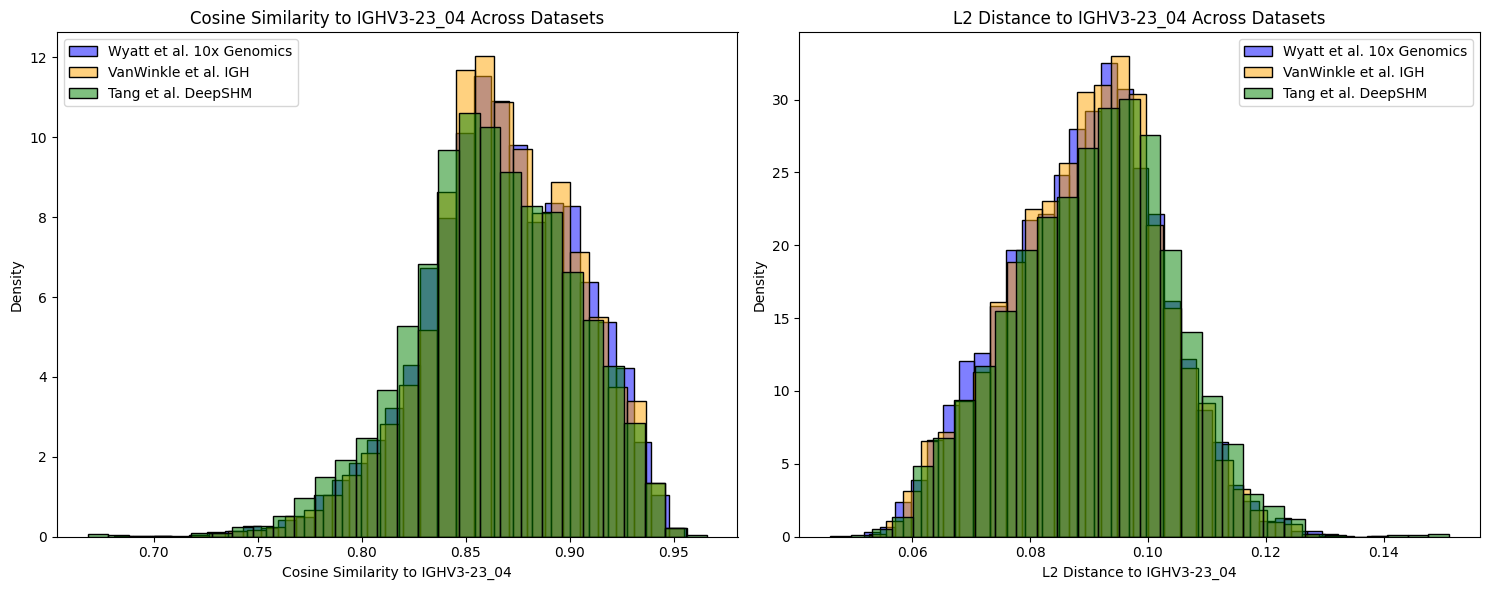

In [26]:
# calculate cosine similarity and L2 distance to IGHV3-23_04_SEQ for each dataset and plot histograms
wyatt_cosine_similarities = [cosine_similarity(vec, ighv3_23_vector) for vec in wyatt_heavy_vectors]
vanwinkle_cosine_similarities = [cosine_similarity(vec, ighv3_23_vector) for vec in vanwinkle_heavy_vectors]
tang_cosine_similarities = [cosine_similarity(vec, ighv3_23_vector) for vec in tang_heavy_vectors]
wyatt_L2_distances = [L2_distance(vec, ighv3_23_vector) for vec in wyatt_heavy_vectors]
vanwinkle_L2_distances = [L2_distance(vec, ighv3_23_vector) for vec in vanwinkle_heavy_vectors]
tang_L2_distances = [L2_distance(vec, ighv3_23_vector) for vec in tang_heavy_vectors]

# plot cosine similarity and L2 distance histograms side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.histplot(wyatt_cosine_similarities, color='blue', label='Wyatt et al. 10x Genomics', stat='density', bins=30, alpha=0.5, ax=axes[0])
sns.histplot(vanwinkle_cosine_similarities, color='orange', label='VanWinkle et al. IGH', stat='density', bins=30, alpha=0.5, ax=axes[0])
sns.histplot(tang_cosine_similarities, color='green', label='Tang et al. DeepSHM', stat='density', bins=30, alpha=0.5, ax=axes[0])
axes[0].set_xlabel('Cosine Similarity to IGHV3-23_04')
axes[0].set_ylabel('Density')
axes[0].set_title('Cosine Similarity to IGHV3-23_04 Across Datasets')
axes[0].legend()
sns.histplot(wyatt_L2_distances, color='blue', label='Wyatt et al. 10x Genomics', stat='density', bins=30, alpha=0.5, ax=axes[1])
sns.histplot(vanwinkle_L2_distances, color='orange', label='VanWinkle et al. IGH', stat='density', bins=30, alpha=0.5, ax=axes[1])
sns.histplot(tang_L2_distances, color='green', label='Tang et al. DeepSHM', stat='density', bins=30, alpha=0.5, ax=axes[1])
axes[1].set_xlabel('L2 Distance to IGHV3-23_04')
axes[1].set_ylabel('Density')
axes[1].set_title('L2 Distance to IGHV3-23_04 Across Datasets')
axes[1].legend()
plt.tight_layout()
plt.show()

100%|██████████| 1000/1000 [00:00<00:00, 6811.53it/s]


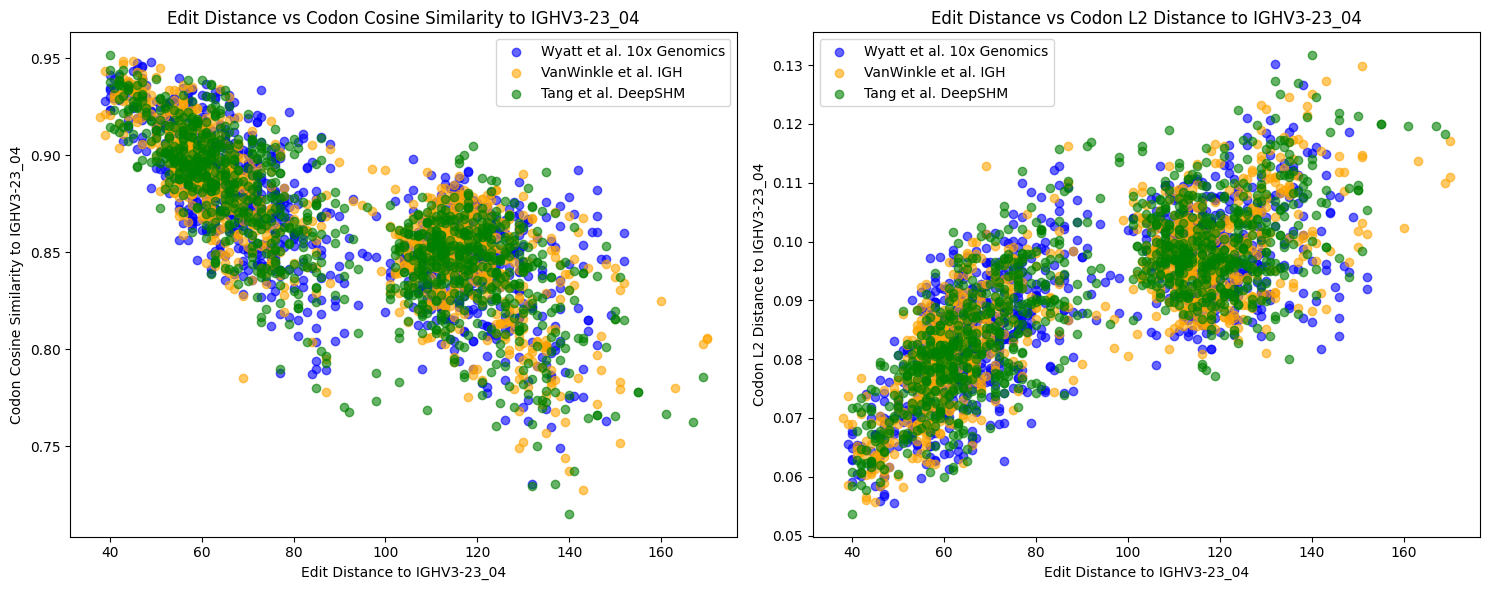

In [27]:
# for each dataset, sample n_samples and compute both the edit distance to IGHV3-23_04 and the codon cosine similarity to IGHV3-23_04, then plot a scatter plot of edit distance (in sequence space) vs cosine similarity (in codon frequency space)
n_samples = 1000
seed = 1

wyatt_sampled = wyatt_df.sample(n=min(n_samples, len(wyatt_df)), random_state=seed)
vanwinkle_sampled = vanwinkle_igh_df.sample(n=min(n_samples, len(vanwinkle_igh_df)), random_state=seed)
tang_sampled = tang_df.sample(n=min(n_samples, len(tang_df)), random_state=seed)

wyatt_edit_distances = wyatt_sampled.progress_apply(lambda x: editdistance.eval(remove_all_gaps(x.parent_heavy), KOENIG_IGH_CON_SEQ), axis=1)
vanwinkle_edit_distances = vanwinkle_sampled.progress_apply(lambda x: editdistance.eval(remove_all_gaps(x.parent_heavy), KOENIG_IGH_CON_SEQ), axis=1)
tang_edit_distances = tang_sampled.progress_apply(lambda x: editdistance.eval(remove_all_gaps(x.parent_heavy), KOENIG_IGH_CON_SEQ), axis=1)

wyatt_codon_similarities = wyatt_sampled['parent_heavy'].progress_apply(lambda x: cosine_similarity(get_codon_frequency_vector(x, valid_codons), ighv3_23_vector))
vanwinkle_codon_similarities = vanwinkle_sampled['parent_heavy'].progress_apply(lambda x: cosine_similarity(get_codon_frequency_vector(x, valid_codons), ighv3_23_vector))
tang_codon_similarities = tang_sampled['parent_heavy'].progress_apply(lambda x: cosine_similarity(get_codon_frequency_vector(x, valid_codons), ighv3_23_vector))

wyatt_L2_distances = wyatt_sampled['parent_heavy'].progress_apply(lambda x: L2_distance(get_codon_frequency_vector(x, valid_codons), ighv3_23_vector))
vanwinkle_L2_distances = vanwinkle_sampled['parent_heavy'].progress_apply(lambda x: L2_distance(get_codon_frequency_vector(x, valid_codons), ighv3_23_vector))
tang_L2_distances = tang_sampled['parent_heavy'].progress_apply(lambda x: L2_distance(get_codon_frequency_vector(x, valid_codons), ighv3_23_vector))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].scatter(wyatt_edit_distances, wyatt_codon_similarities, color='blue', label='Wyatt et al. 10x Genomics', alpha=0.6)
axes[0].scatter(vanwinkle_edit_distances, vanwinkle_codon_similarities, color='orange', label='VanWinkle et al. IGH', alpha=0.6)
axes[0].scatter(tang_edit_distances, tang_codon_similarities, color='green', label='Tang et al. DeepSHM', alpha=0.6)
axes[0].set_xlabel('Edit Distance to IGHV3-23_04')
axes[0].set_ylabel('Codon Cosine Similarity to IGHV3-23_04')
axes[0].set_title('Edit Distance vs Codon Cosine Similarity to IGHV3-23_04')
axes[0].legend()

axes[1].scatter(wyatt_edit_distances, wyatt_L2_distances, color='blue', label='Wyatt et al. 10x Genomics', alpha=0.6)
axes[1].scatter(vanwinkle_edit_distances, vanwinkle_L2_distances, color='orange', label='VanWinkle et al. IGH', alpha=0.6)
axes[1].scatter(tang_edit_distances, tang_L2_distances, color='green', label='Tang et al. DeepSHM', alpha=0.6)
axes[1].set_xlabel('Edit Distance to IGHV3-23_04')
axes[1].set_ylabel('Codon L2 Distance to IGHV3-23_04')
axes[1].set_title('Edit Distance vs Codon L2 Distance to IGHV3-23_04')
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
# umap visualization of the codon frequency vectors colored by dataset, also plot IGHV3-23_04_SEQ point
import umap
all_vectors = wyatt_heavy_vectors + vanwinkle_heavy_vectors + tang_heavy_vectors
labels = (['Wyatt et al. 10x Genomics'] * len(wyatt_heavy_vectors) +
          ['VanWinkle et al. IGH'] * len(vanwinkle_heavy_vectors) +
          ['Tang et al. DeepSHM'] * len(tang_heavy_vectors))
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(all_vectors + [ighv3_23_vector])
embedding_df = pd.DataFrame(embedding[:-1], columns=['UMAP1', 'UMAP2'])
embedding_df['Dataset'] = labels
ighv3_23_embedding = embedding[-1]

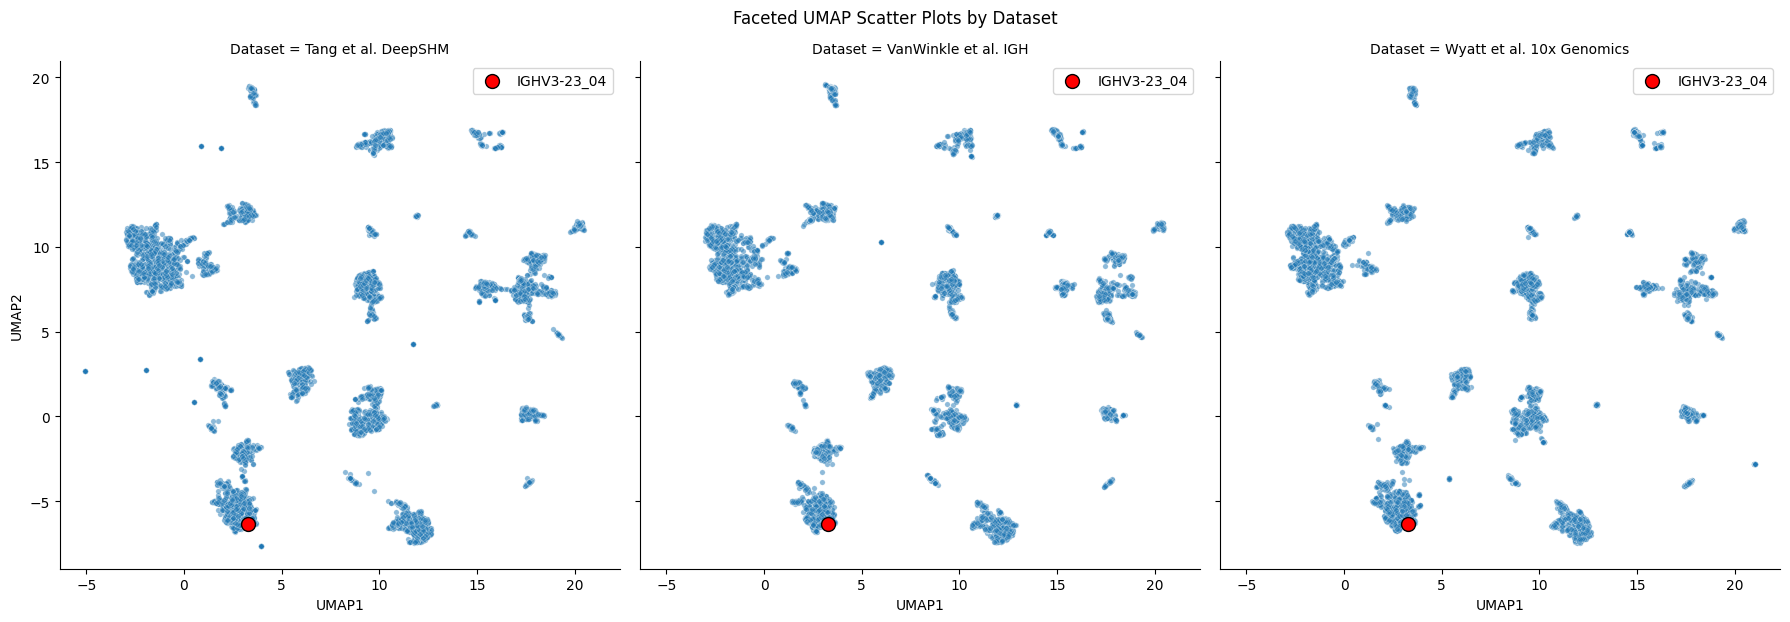

In [104]:
# Create a combined dataframe for faceting
embedding_with_ighv3 = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
embedding_with_ighv3['Dataset'] = labels + ['IGHV3-23_04']
embedding_with_ighv3['Point_Type'] = (['Sample'] * len(labels)) + ['Reference']

# Create a FacetGrid, making one column per 'Dataset'
g = sns.FacetGrid(embedding_df, col="Dataset", height=6)

# Map a scatterplot onto each facet
g.map_dataframe(sns.scatterplot, x='UMAP1', y='UMAP2', s=15, alpha=0.5)

# To add the single point to each facet, we can iterate through the axes
for ax in g.axes.flat:
    ax.scatter(
        ighv3_23_embedding[0],
        ighv3_23_embedding[1],
        color='red',
        s=100,
        label='IGHV3-23_04',
        edgecolor='black',
        zorder=5
    )
    ax.legend() # Add a legend to each subplot

# Add an overall title
g.fig.suptitle('Faceted UMAP Scatter Plots by Dataset', y=1.03) # y adjusts title position
plt.show()

In [28]:
from evo.sequence import HUMAN_CODON_USAGE

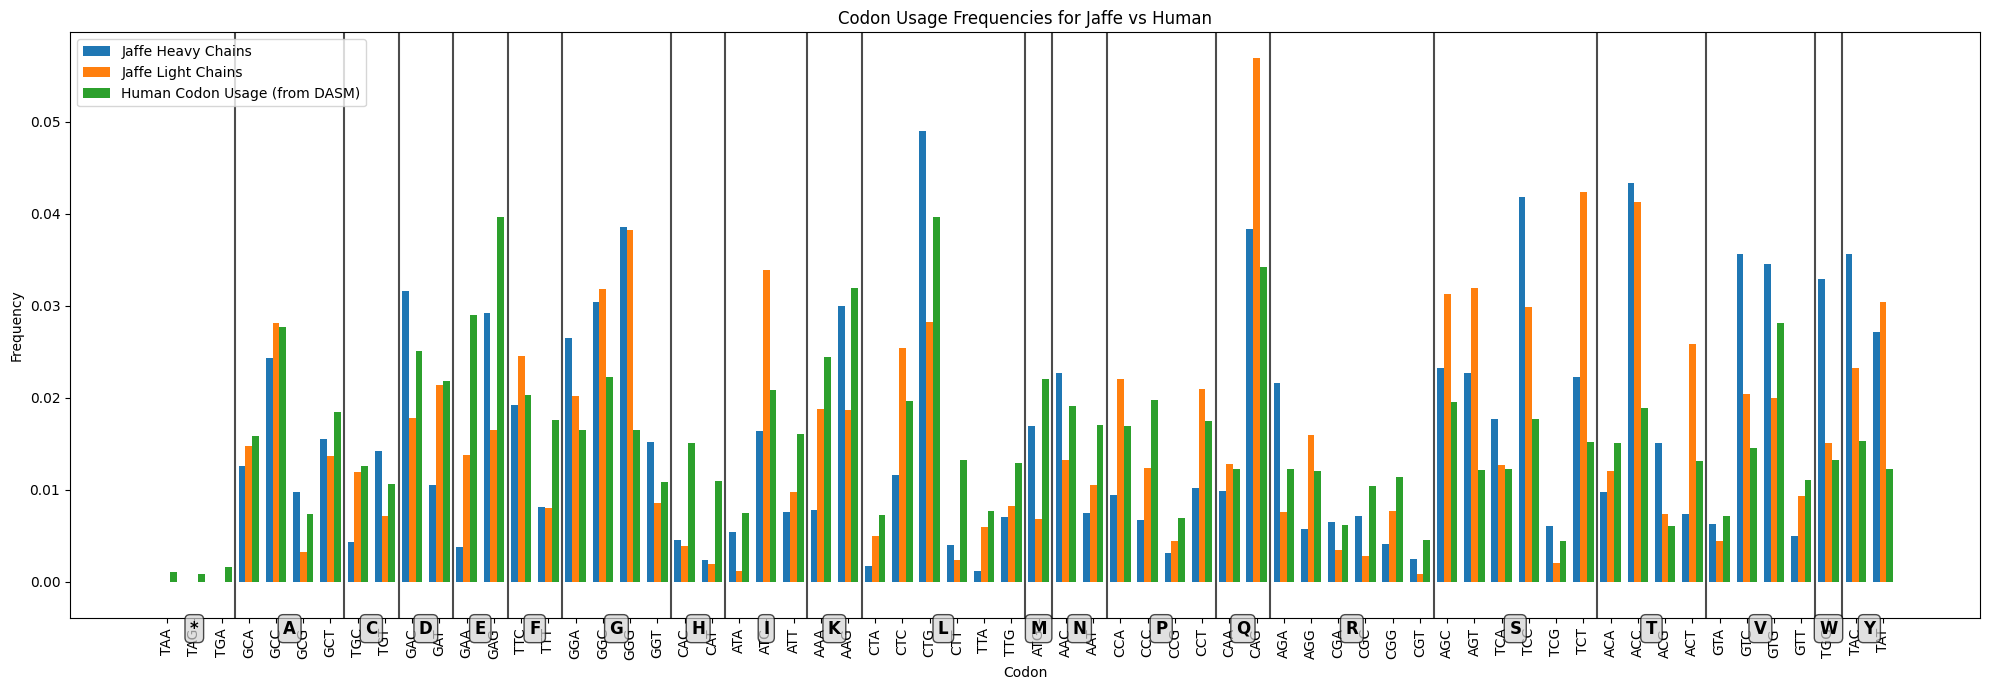

In [29]:
from collections import OrderedDict

# Get valid codons
codons = sorted([c for c in HUMAN_CODON_USAGE.keys() if len(c) == 3 and set(c).issubset({'A', 'T', 'G', 'C'})])
norm_human_total = sum(HUMAN_CODON_USAGE.values())

# Create proper codon to amino acid mapping
codon_to_aa = {}
for c in codons:
    try:
        aa = str(Seq(c).translate())
        codon_to_aa[c] = aa
    except:
        continue  # Skip invalid codons

# Filter codons to only those with valid translations
valid_codons = [c for c in codons if c in codon_to_aa]

# **KEY FIX**: Sort codons by amino acid first, then by codon
# This ensures all codons for the same AA are grouped together
valid_codons = sorted(valid_codons, key=lambda c: (codon_to_aa[c], c))

# Now get frequencies for the properly sorted codons
jaffe_heavy_freqs = [jaffe_heavy_counts.get(codon, 0) / sum(jaffe_heavy_counts.values()) for codon in valid_codons]
jaffe_light_freqs = [jaffe_light_counts.get(codon, 0) / sum(jaffe_light_counts.values()) for codon in valid_codons]
human_codon_freqs = [HUMAN_CODON_USAGE[codon] / norm_human_total for codon in valid_codons]

# Build ordered groups by amino acid
aa_groups = OrderedDict()
for i, c in enumerate(valid_codons):
    aa = codon_to_aa[c]
    aa_groups.setdefault(aa, []).append((i, c))

# Prepare plot
x = np.arange(len(valid_codons))
width = 0.25  # width of the bars

fig, ax = plt.subplots(figsize=(20, 7))
ax.bar(x - width, jaffe_heavy_freqs, width, label='Jaffe Heavy Chains')
ax.bar(x, jaffe_light_freqs, width, label='Jaffe Light Chains')
ax.bar(x + width, human_codon_freqs, width, label='Human Codon Usage (from DASM)')

# Set ticks and codon labels
ax.set_xticks(x)
ax.set_xticklabels(valid_codons, rotation=90)
ax.set_xlabel('Codon')
ax.set_ylabel('Frequency')
ax.set_title('Codon Usage Frequencies for Jaffe vs Human')

# Draw group separators and add amino-acid labels
for aa, items in aa_groups.items():
    indices = [idx for idx, _ in items]
    left = min(indices)
    right = max(indices)
    center = (left + right) / 2.0
    
    # Vertical separator at the right edge of the group (except after last group)
    if right < len(valid_codons) - 1:
        ax.axvline(right + 0.5, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
    
    # Place amino-acid labels below the x-axis at group centers
    ax.text(center, -0.002, aa, transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.7))

# Improve layout
ax.set_ylim(bottom=-0.004)
plt.subplots_adjust(bottom=0.15)
ax.legend()
plt.tight_layout()
plt.show()